In [1]:
import torch
import joblib # Untuk menyimpan/memuat objek Python, seperti preprocessor
import numpy as np # Untuk operasi numerik, terutama pada array
import pandas as pd # Untuk manipulasi dan analisis data dalam DataFrame
import tensorflow as tf # Framework utama untuk membangun dan melatih model deep learning
import matplotlib.pyplot as plt # Untuk membuat visualisasi data, seperti plot histori training dan confusion matrix

from sklearn.compose import ColumnTransformer # Menggabungkan transformasi pada kolom yang berbeda
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split # Untuk membagi dataset menjadi subset train, validation, dan test
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Scaler untuk fitur numerik dan encoder untuk fitur kategorikal
from sklearn.metrics import ( # Metrik evaluasi model
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold

In [2]:
# --- Bagian 1: Pemuatan Data dan Konfigurasi Awal ---
print("Memulai proses...")

df = pd.read_csv('heart_clean.csv')
target_column = 'target'

print("\nInformasi Dataset Awal:")
df.info()
print("\nBaris Pertama Dataset Awal:")
print(df.head())

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Memulai proses...

Informasi Dataset Awal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3235 entries, 0 to 3234
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       3235 non-null   float64
 1   sex       3235 non-null   int64  
 2   cp        3235 non-null   int64  
 3   trestbps  3235 non-null   float64
 4   chol      3235 non-null   float64
 5   fbs       3235 non-null   int64  
 6   restecg   3235 non-null   int64  
 7   thalach   3235 non-null   float64
 8   exang     3235 non-null   int64  
 9   oldpeak   3235 non-null   float64
 10  slope     3235 non-null   int64  
 11  target    3235 non-null   int64  
dtypes: float64(5), int64(7)
memory usage: 303.4 KB

Baris Pertama Dataset Awal:
    age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  40.0    1   2     140.0  289.0    0        0    172.0      0      0.0   
1  49.0    0   3     160.0  180.0    0        0    156.0      0      1.

In [3]:
# --- Bagian 2: Pemisahan Fitur dan Target ---
try:
    y_series = df[target_column]
    X_df = df.drop(target_column, axis=1)
    X_df = X_df[categorical_cols + numerical_cols]
except KeyError as e:
    print(f"Error saat memisahkan fitur dan target: Kolom '{e}' tidak ditemukan. Harap periksa nama kolom target.")
    exit()

print("\n--- Isi Variabel Setelah Pemisahan Fitur dan Target ---")
print("\nIsi y_series (Target):")
print(y_series.head())
print(f"Bentuk y_series: {y_series.shape}")

print("\nIsi X_df (Fitur):")
print(X_df.head())
print(f"Bentuk X_df: {X_df.shape}")


--- Isi Variabel Setelah Pemisahan Fitur dan Target ---

Isi y_series (Target):
0    0
1    1
2    0
3    1
4    0
Name: target, dtype: int64
Bentuk y_series: (3235,)

Isi X_df (Fitur):
   sex  cp  fbs  restecg  exang  slope   age  trestbps   chol  thalach  \
0    1   2    0        0      0      1  40.0     140.0  289.0    172.0   
1    0   3    0        0      0      2  49.0     160.0  180.0    156.0   
2    1   2    0        1      0      1  37.0     130.0  283.0     98.0   
3    0   4    0        0      1      2  48.0     138.0  214.0    108.0   
4    1   3    0        0      0      1  54.0     150.0  195.0    122.0   

   oldpeak  
0      0.0  
1      1.0  
2      0.0  
3      1.5  
4      0.0  
Bentuk X_df: (3235, 11)


In [4]:
# --- Bagian 3: Preprocessing Data dengan ColumnTransformer ---
# ColumnTransformer digunakan untuk menerapkan transformasi yang berbeda pada kolom yang berbeda.
# StandardScaler untuk kolom numerik (menskala data sehingga memiliki mean 0 dan variance 1).
# OneHotEncoder untuk kolom kategorikal (mengubah fitur kategorikal menjadi representasi biner,
# cocok untuk input model neural network).
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols), # Terapkan StandardScaler pada kolom numerik
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols) # Terapkan OneHotEncoder pada kolom kategorikal
    ],
    remainder='drop' # Kolom yang tidak disebutkan di 'transformers' akan dibuang
)

In [5]:
# --- Bagian 4: Pembagian Data Train, Validation, dan Test ---
X_train_df, X_temp_df, y_train_series, y_temp_series = train_test_split(
    X_df, y_series, test_size=0.2, random_state=42, stratify=y_series
)
X_val_df, X_test_df, y_val_series, y_test_series = train_test_split(
    X_temp_df, y_temp_series, test_size=0.5, random_state=42, stratify=y_temp_series
)

print(f"\n--- Isi Variabel Setelah Pembagian Data (Sebelum Preprocessing) ---")
print(f"Data Training   : {X_train_df.shape[0]} sampel")
print(f"Data Validation : {X_val_df.shape[0]} sampel")
print(f"Data Test       : {X_test_df.shape[0]} sampel")

print("\nLima Baris Pertama X_train_df:")
print(X_train_df.head())
print(f"Bentuk X_train_df: {X_train_df.shape}")

print("\nLima Baris Pertama y_train_series:")
print(y_train_series.head())
print(f"Bentuk y_train_series: {y_train_series.shape}")

print("\nLima Baris Pertama X_temp_df:")
print(X_temp_df.head())
print(f"Bentuk X_temp_df: {X_temp_df.shape}")

print("\nLima Baris Pertama y_temp_series:")
print(y_temp_series.head())
print(f"Bentuk y_temp_series: {y_temp_series.shape}")

print("\nLima Baris Pertama X_val_df:")
print(X_val_df.head())
print(f"Bentuk X_val_df: {X_val_df.shape}")

print("\nLima Baris Pertama y_val_series:")
print(y_val_series.head())
print(f"Bentuk y_val_series: {y_val_series.shape}")

print("\nLima Baris Pertama X_test_df:")
print(X_test_df.head())
print(f"Bentuk X_test_df: {X_test_df.shape}")

print("\nLima Baris Pertama y_test_series:")
print(y_test_series.head())
print(f"Bentuk y_test_series: {y_test_series.shape}")


--- Isi Variabel Setelah Pembagian Data (Sebelum Preprocessing) ---
Data Training   : 2588 sampel
Data Validation : 323 sampel
Data Test       : 324 sampel

Lima Baris Pertama X_train_df:
      sex  cp  fbs  restecg  exang  slope   age  trestbps   chol  thalach  \
1279    1   2    1        1      0      2  48.0     124.0  255.0    175.0   
2747    0   2    0        0      0      2  57.0     130.0  236.0    174.0   
1071    0   2    0        0      0      1  63.0     140.0  195.0    179.0   
1163    0   3    0        0      0      2  39.0     138.0  220.0    152.0   
2849    1   1    0        0      0      2  70.0     130.0  322.0    109.0   

      oldpeak  
1279      0.0  
2747      0.0  
1071      0.0  
1163      0.0  
2849      2.4  
Bentuk X_train_df: (2588, 11)

Lima Baris Pertama y_train_series:
1279    1
2747    0
1071    0
1163    0
2849    0
Name: target, dtype: int64
Bentuk y_train_series: (2588,)

Lima Baris Pertama X_temp_df:
      sex  cp  fbs  restecg  exang  slope   age

In [6]:
# --- Bagian 5: Menerapkan Preprocessing ---
try:
    X_train_processed = preprocessor.fit_transform(X_train_df)
    X_val_processed = preprocessor.transform(X_val_df)
    X_test_processed = preprocessor.transform(X_test_df)
    print(f"\nBentuk data setelah preprocessing:")
    print(f"  Training      : {X_train_processed.shape} (jumlah sampel, jumlah fitur)")
    print(f"  Validation    : {X_val_processed.shape}")
    print(f"  Test          : {X_test_processed.shape}")
except Exception as e:
    print(f"Error saat menerapkan preprocessor: {e}")
    exit()

print("\n--- Isi Variabel Setelah Preprocessing ---")
print("\nLima Baris Pertama X_train_processed:")
# Karena ini adalah array NumPy, kita bisa melihat beberapa baris pertama
print(X_train_processed[:5])
print(f"Bentuk X_train_processed: {X_train_processed.shape}")

print("\nLima Baris Pertama X_val_processed:")
print(X_val_processed[:5])
print(f"Bentuk X_val_processed: {X_val_processed.shape}")

print("\nLima Baris Pertama X_test_processed:")
print(X_test_processed[:5])
print(f"Bentuk X_test_processed: {X_test_processed.shape}")

# Simpan objek preprocessor
preprocessor_tf_path = 'tf_ohe_preprocessor.pkl'
joblib.dump(preprocessor, preprocessor_tf_path)
print(f"\nPreprocessor disimpan di: {preprocessor_tf_path}")

# Mengubah Series target menjadi array NumPy
y_train_np = y_train_series.values
y_val_np = y_val_series.values
y_test_np = y_test_series.values

print("\n--- Isi Array Target (Setelah Konversi ke NumPy) ---")
print("\nLima Baris Pertama y_train_np:")
print(y_train_np[:5])
print(f"Bentuk y_train_np: {y_train_np.shape}")

print("\nLima Baris Pertama y_val_np:")
print(y_val_np[:5])
print(f"Bentuk y_val_np: {y_val_np.shape}")

print("\nLima Baris Pertama y_test_np:")
print(y_test_np[:5])
print(f"Bentuk y_test_np: {y_test_np.shape}")


Bentuk data setelah preprocessing:
  Training      : (2588, 21) (jumlah sampel, jumlah fitur)
  Validation    : (323, 21)
  Test          : (324, 21)

--- Isi Variabel Setelah Preprocessing ---

Lima Baris Pertama X_train_processed:
[[-0.66846645 -0.44774105  0.32891506  1.23175451 -0.88196322  0.
   1.          0.          1.          0.          0.          0.
   1.          0.          1.          0.          1.          0.
   0.          1.          0.        ]
 [ 0.30419765 -0.09045018  0.01761254  1.19129453 -0.88196322  1.
   0.          0.          1.          0.          0.          1.
   0.          1.          0.          0.          1.          0.
   0.          1.          0.        ]
 [ 0.95264038  0.5050346  -0.65414553  1.3935944  -0.88196322  1.
   0.          0.          1.          0.          0.          1.
   0.          1.          0.          0.          1.          0.
   1.          0.          0.        ]
 [-1.64113055  0.38593764 -0.24453695  0.3011751  -0.88

In [7]:
# --- Bagian 6: Konversi X dan y ke float32 (TabNet memerlukan tipe ini) ---
X_train_float = X_train_processed.astype(np.float32)
X_val_float = X_val_processed.astype(np.float32)
X_test_float = X_test_processed.astype(np.float32)

y_train_int = y_train_np.astype(int)
y_val_int = y_val_np.astype(int)
y_test_int = y_test_np.astype(int)

In [10]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

accuracies = []
precisions = []
recalls = []
f1s = []

fold = 1
for train_index, val_index in skf.split(X_train_processed, y_train_np):
    print(f"\n🔁 Fold {fold}")

    # Ambil data train & validasi untuk fold ini
    X_train_fold = X_train_processed[train_index].astype(np.float32)
    y_train_fold = y_train_np[train_index].astype(int)
    X_val_fold = X_train_processed[val_index].astype(np.float32)
    y_val_fold = y_train_np[val_index].astype(int)

    # Inisialisasi ulang model untuk tiap fold
    clf = TabNetClassifier(
        n_d=32, n_a=32, n_steps=7,
        gamma=1.5, lambda_sparse=1e-4,
        mask_type='entmax',
        optimizer_fn=torch.optim.AdamW,
        optimizer_params=dict(lr=1e-3),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={"step_size": 10, "gamma": 0.95},
        seed=42,
        verbose=0
    )

    clf.fit(
        X_train=X_train_fold, y_train=y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        eval_name=['val'],
        eval_metric=['accuracy'],
        max_epochs=100,
        patience=20,
        batch_size=1024,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False
    )

    # Prediksi dan evaluasi
    y_pred_fold = clf.predict(X_val_fold)
    acc = accuracy_score(y_val_fold, y_pred_fold)
    prec = precision_score(y_val_fold, y_pred_fold)
    rec = recall_score(y_val_fold, y_pred_fold)
    f1 = f1_score(y_val_fold, y_pred_fold)

    print(f"Accuracy : {acc:.4f}, Precision : {prec:.4f}, Recall : {rec:.4f}, F1 : {f1:.4f}")

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    fold += 1



🔁 Fold 1

Early stopping occurred at epoch 65 with best_epoch = 45 and best_val_accuracy = 0.70077
Accuracy : 0.7008, Precision : 0.7017, Recall : 0.7555, F1 : 0.7276

🔁 Fold 2


c:\Users\rizky\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 88 with best_epoch = 68 and best_val_accuracy = 0.72201
Accuracy : 0.7220, Precision : 0.7257, Recall : 0.7628, F1 : 0.7438

🔁 Fold 3


c:\Users\rizky\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 100 with best_epoch = 88 and best_val_accuracy = 0.75097
Accuracy : 0.7510, Precision : 0.7628, Recall : 0.7656, F1 : 0.7642

🔁 Fold 4


c:\Users\rizky\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 50 with best_epoch = 30 and best_val_accuracy = 0.70986
Accuracy : 0.7099, Precision : 0.7113, Recall : 0.7582, F1 : 0.7340

🔁 Fold 5


c:\Users\rizky\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 100 with best_epoch = 93 and best_val_accuracy = 0.76789
Accuracy : 0.7679, Precision : 0.7823, Recall : 0.7766, F1 : 0.7794


c:\Users\rizky\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # Nonaktifkan GPU jika tidak tersedia

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# --- Load Dataset ---
print("Memulai proses...")

df = pd.read_csv('heart_clean.csv')
target_column = 'target'

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Pastikan kolom kategorikal bertipe int
for col in categorical_cols:
    df[col] = df[col].astype(int)

# Simpan salinan df asli
X_df = df[categorical_cols + numerical_cols].copy()

# Hanya normalisasi kolom numerikal
scaler = MinMaxScaler()
X_df[numerical_cols] = scaler.fit_transform(X_df[numerical_cols])

X_df = df[categorical_cols + numerical_cols]
y = df[target_column].astype(int).values
X = X_df.values

cat_idxs = [X_df.columns.get_loc(col) for col in categorical_cols]
cat_dims = [df[col].nunique() for col in categorical_cols]

# --- K-Fold Cross Validation ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_list = []
precision_list = []
recall_list = []
models_per_fold = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n=== Fold {fold} ===")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    clf = TabNetClassifier(
        n_d=32, n_a=32, n_steps=7,
        gamma=1.5, lambda_sparse=1e-4,
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        cat_emb_dim=3,
        optimizer_fn=torch.optim.AdamW,
        optimizer_params=dict(lr=1e-4),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={"step_size": 30, "gamma": 0.95},
        seed=42,
        verbose=0
    )

    clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_val, y_val)],
        eval_name=['val'],
        eval_metric=['accuracy'],
        max_epochs=2000,
        patience=150,
        batch_size=1024,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False
    )

    y_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)

    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    models_per_fold.append((clf, acc))

    print(f"Akurasi  : {acc:.4f}")
    print(f"Presisi  : {prec:.4f}")
    print(f"Recall   : {rec:.4f}")

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()

# --- Rata-rata Hasil Evaluasi ---
print("\n=== Rata-rata Hasil Evaluasi (5 Fold) ===")
print(f"Akurasi rata-rata  : {np.mean(accuracy_list):.4f}")
print(f"Presisi rata-rata  : {np.mean(precision_list):.4f}")
print(f"Recall rata-rata   : {np.mean(recall_list):.4f}")

# --- Simpan Model Terbaik dan Scaler ---
best_index = np.argmax(accuracy_list)
best_model = models_per_fold[best_index][0]

MODEL_PATH = "best_tabnet_model.zip"
SCALER_PATH = "minmax_scaler.pkl"

best_model.save_model(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print(f"\n✅ Model terbaik (Fold {best_index+1}) disimpan ke: {MODEL_PATH}")
print(f"✅ Scaler disimpan ke: {SCALER_PATH}")

Memulai proses...

=== Fold 1 ===


C:\Users\rizky\AppData\Local\Temp\ipykernel_18692\3107232999.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_df[numerical_cols] = scaler.fit_transform(X_df[numerical_cols])



Early stopping occurred at epoch 820 with best_epoch = 670 and best_val_accuracy = 0.69397
Akurasi  : 0.6940
Presisi  : 0.6981
Recall   : 0.7390


c:\Users\rizky\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


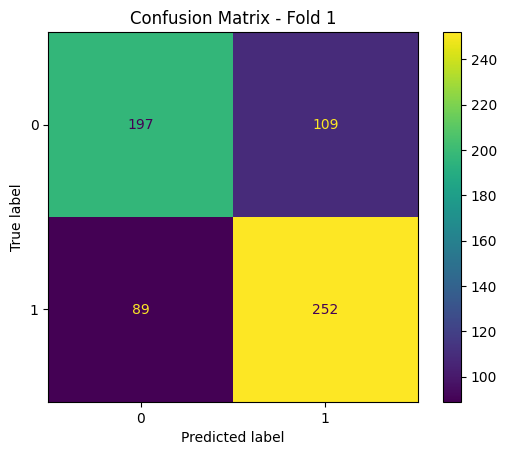


=== Fold 2 ===

Early stopping occurred at epoch 1256 with best_epoch = 1106 and best_val_accuracy = 0.72798
Akurasi  : 0.7280
Presisi  : 0.7399
Recall   : 0.7485


c:\Users\rizky\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


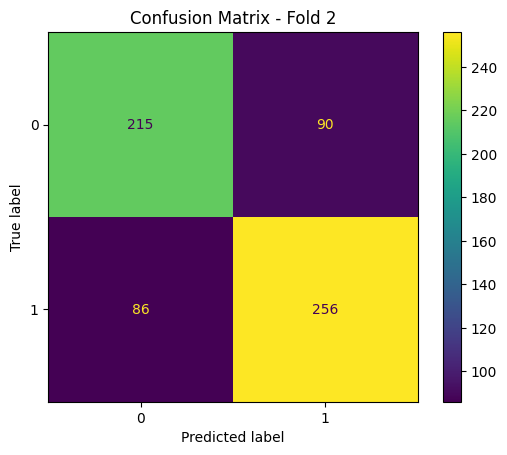


=== Fold 3 ===

Early stopping occurred at epoch 734 with best_epoch = 584 and best_val_accuracy = 0.68161
Akurasi  : 0.6816
Presisi  : 0.6789
Recall   : 0.7544


c:\Users\rizky\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


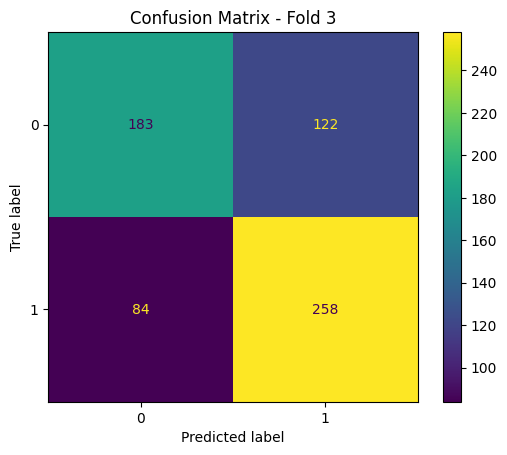


=== Fold 4 ===

Early stopping occurred at epoch 882 with best_epoch = 732 and best_val_accuracy = 0.74652
Akurasi  : 0.7465
Presisi  : 0.7459
Recall   : 0.7895


c:\Users\rizky\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


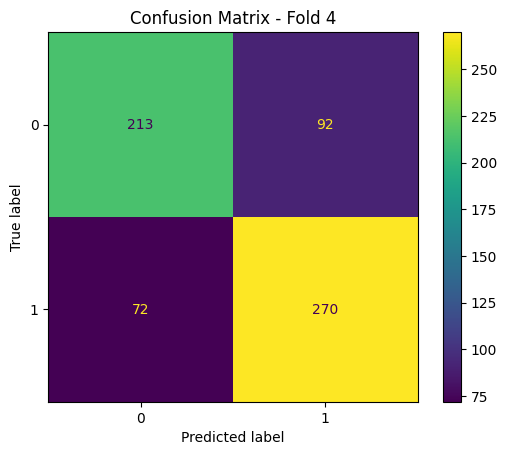


=== Fold 5 ===

Early stopping occurred at epoch 594 with best_epoch = 444 and best_val_accuracy = 0.69397
Akurasi  : 0.6940
Presisi  : 0.6915
Recall   : 0.7602


c:\Users\rizky\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


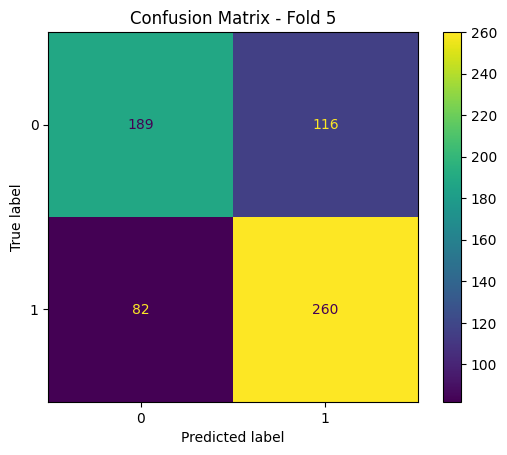


=== Rata-rata Hasil Evaluasi (5 Fold) ===
Akurasi rata-rata  : 0.7088
Presisi rata-rata  : 0.7108
Recall rata-rata   : 0.7583
Successfully saved model at best_tabnet_model.zip

✅ Model terbaik (Fold 4) disimpan ke: best_tabnet_model
✅ Scaler disimpan ke: minmax_scaler.pkl


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# --- Load Dataset ---
print("Memulai proses...")

df = pd.read_csv('heart_clean.csv')
target_column = 'target'

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Pastikan tipe integer
for col in categorical_cols:
    df[col] = df[col].astype(int)

X_df = df[categorical_cols + numerical_cols]
y = df[target_column].astype(int).values

# Normalisasi numerik
scaler = MinMaxScaler()
X_df[numerical_cols] = scaler.fit_transform(X_df[numerical_cols])

X = X_df.values

# Index dan Dimensi untuk kategori
cat_idxs = [X_df.columns.get_loc(col) for col in categorical_cols]
cat_dims = [df[col].max() + 1 for col in categorical_cols]

# --- K-Fold Evaluation ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_list = []
precision_list = []
recall_list = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n=== Fold {fold} ===")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    clf = TabNetClassifier(
        n_d=32, n_a=32, n_steps=7,
        gamma=1.5, lambda_sparse=1e-4,
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        cat_emb_dim=3,
        optimizer_fn=torch.optim.AdamW,
        optimizer_params=dict(lr=1e-4),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={"step_size": 30, "gamma": 0.95},
        seed=42,
        verbose=0
    )

    clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_val, y_val)],
        eval_name=['val'],
        eval_metric=['accuracy'],
        max_epochs=2000,
        patience=150,
        batch_size=1024,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False
    )

    y_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)

    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    models_per_fold.append((clf, acc))

    print(f"Akurasi  : {acc:.4f}")
    print(f"Presisi  : {prec:.4f}")
    print(f"Recall   : {rec:.4f}")

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()

# --- Rata-rata Hasil Evaluasi ---
print("\n=== Rata-rata Hasil Evaluasi (5 Fold) ===")
print(f"Akurasi rata-rata  : {np.mean(accuracy_list):.4f}")
print(f"Presisi rata-rata  : {np.mean(precision_list):.4f}")
print(f"Recall rata-rata   : {np.mean(recall_list):.4f}")

# --- Simpan Model Terbaik dan Scaler ---

# Ambil index fold dengan akurasi terbaik
best_index = np.argmax(accuracy_list)
best_model = models_per_fold[best_index][0]  # model dari fold terbaik

# Path file output
MODEL_DIR = "best_tabnet_model"  # Tanpa ekstensi: akan dibuat .zip, .json, .pth
SCALER_PATH = "minmax_scaler.pkl"

# Simpan model TabNet dalam format zip/json/pth
best_model.save_model(MODEL_DIR)

# Simpan scaler MinMaxScaler dengan joblib
joblib.dump(scaler, SCALER_PATH, protocol=4)

# Konfirmasi
print(f"\n✅ Model terbaik (Fold {best_index+1}) disimpan ke: {MODEL_DIR}")
print(f"✅ Scaler disimpan ke: {SCALER_PATH}")